## Assignment 10 - Deadline: Dec 31, 2025, Wed 11pm

#### DSAI 510 Fall 2025

Complete the assignment below and upload <span style="color:red">both the .ipynb file and its pdf</span> to https://moodle.boun.edu.tr by the deadline given above. The submission page on Moodle will close automatically after this date and time.


To make a pdf, this may work: Hit CMD+P or CTRL+P, and save it as PDF. You may also use other options from the File menu.

In [29]:
# Run this cell first

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Set the display option to show all rows scrolling with a slider
# pd.set_option('display.max_rows', None)
# To disable this, run the line below:
# pd.reset_option('display.max_rows')

## Note: 
In the problems below, if they ask "show the number of records that are nonzero", 
the answer is a number; so you don't need to show the records themselves.
But if it asks, "show the records with NaN", it wants you to print those records (rows)
containing NAN and other entries, not asking how many such records there are. So be careful about what you're asked.

# Total: 80 pts

# Problem 1: New York City Taxi Fare dataset (40 pts)

The dataset below contains data between 2009-01-02 02:32:41 and 2015-06-30 22:42:39. 
1) Create a new column named `Man_distance` that contains the Manhattan distance between the pick-up and drop-off location, measured in kilometers.
2) Create a new column named `fare_per_km` that contains `fare_amount / Man_distance`.
3) Create a plot showing how `fare_per_km` changes from 2009-01-02 02:32:41 to 2015-06-30 22:42:39.
4) Suggest two possible reasons for this change (there's no right or wrong answer here).
5) Create a new column `month` that contains the month of the trip date (Jan, Feb, ..., Nov, Dec). Then create another plot showing how `fare_per_km` varies with `month`. 
6) Is there a change in `fare_per_km` with respect to months? If yes, guess two possible reasons for this change (there's no right or wrong answer here).

In [30]:
df = pd.read_csv('./NYC-taxi-fare-first_3000_rows.csv')
df.head()

,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,2009-06-15 17:26:21.0000001,4.5,2009-06-15 17:26:21 UTC,-73.844311,40.721319,-73.841610,40.712278,1
1,2010-01-05 16:52:16.0000002,16.9,2010-01-05 16:52:16 UTC,-74.016048,40.711303,-73.979268,40.782004,1
2,2011-08-18 00:35:00.00000049,5.7,2011-08-18 00:35:00 UTC,-73.982738,40.761270,-73.991242,40.750562,2
3,2012-04-21 04:30:42.0000001,7.7,2012-04-21 04:30:42 UTC,-73.987130,40.733143,-73.991567,40.758092,1
4,2010-03-09 07:51:00.000000135,5.3,2010-03-09 07:51:00 UTC,-73.968095,40.768008,-73.956655,40.783762,1


In [31]:
print(min(df.key))
print(max(df.key))

2009-01-02 02:32:41.0000001
2015-06-30 22:42:39.00000014


In [32]:
df['fare_amount'].min() # there's a negative value?

np.float64(-2.9)

In [33]:
df = df[df['fare_amount'] > 0]

In [34]:
km_per_lat = 111.32 # constant for km per degree of latitude
km_per_lon = 111.32 * np.cos(np.radians(df['pickup_latitude'])) # specific km per degree of longitude

df['Man_distance'] = (
    np.abs(df['pickup_latitude'] - df['dropoff_latitude']) * km_per_lat + 
    np.abs(df['pickup_longitude'] - df['dropoff_longitude']) * km_per_lon
)

print(df['Man_distance'].min()) # there are 0 values
print(df['Man_distance'].max()) # there are huge values as well

0.0
12771.979375759998


949.4774307564628
(2877, 10)


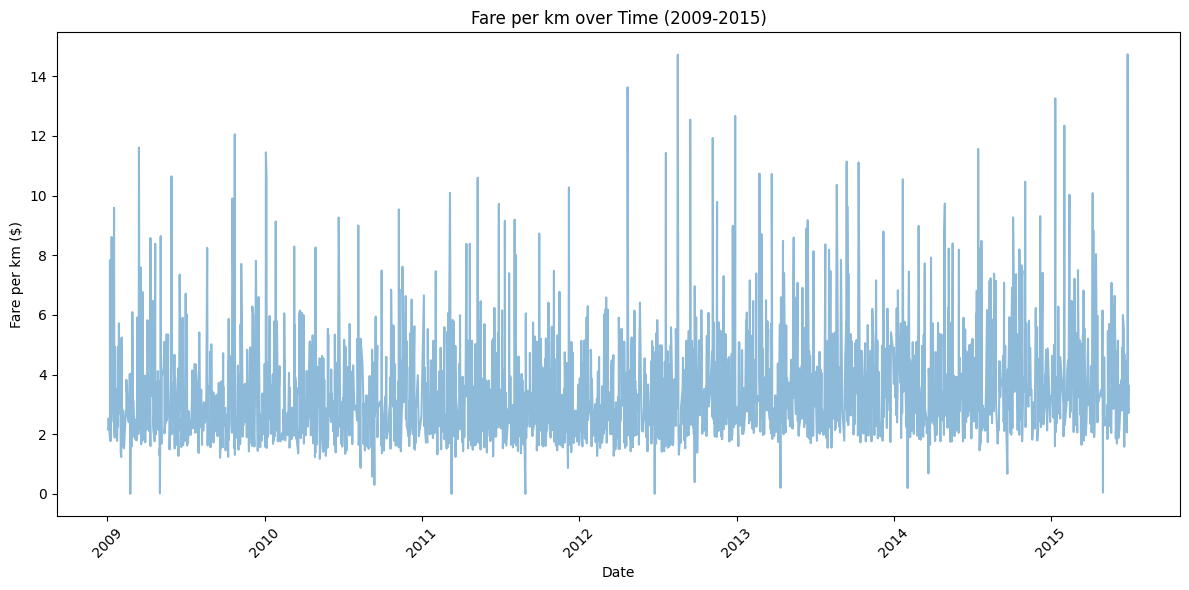

In [35]:
# 2)
df = df[df['Man_distance'] > 0]
df['fare_per_km'] = df['fare_amount'] / df['Man_distance']

print(df[df['fare_per_km'] < 1000]['fare_per_km'].max()) 
# there are still huge values, due to some taxi app glitch? 
# probably due to high manhattan distance.
# just in case and to be safe, i'll only accept below 15 f/km. 
# only ~123 data is lost. Also, now it looks more like a time series plot.
df = df[df['fare_per_km'] < 15]
print(df.shape)

# 3)
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])
df = df[(df['pickup_datetime'] >= '2009-01-02 02:32:41') & 
        (df['pickup_datetime'] <= '2015-06-30 22:42:39')]

df_sorted = df.sort_values('pickup_datetime')

plt.figure(figsize=(12, 6))
plt.plot(df_sorted['pickup_datetime'], df_sorted['fare_per_km'], alpha=0.5)
plt.xlabel('Date')
plt.ylabel('Fare per km ($)')
plt.title('Fare per km over Time (2009-2015)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [36]:
# 4)
# 1 - Inflation: Taxi fares might be increased over time due to gas price changes
# 2 - Regulatory changes: Taxi center might adjust base fares

# 5)
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

df['month'] = df['pickup_datetime'].dt.strftime('%b')

monthly_avg = df.groupby('month')['fare_per_km'].mean().reindex(month_order)
monthly_avg

month
Jan    3.529257
Feb    3.249182
Mar    3.335170
Apr    3.384659
May    3.233273
Jun    3.350890
Jul    3.219968
Aug    3.278824
Sep    3.353242
Oct    3.529430
Nov    3.445158
Dec    3.403978
Name: fare_per_km, dtype: float64

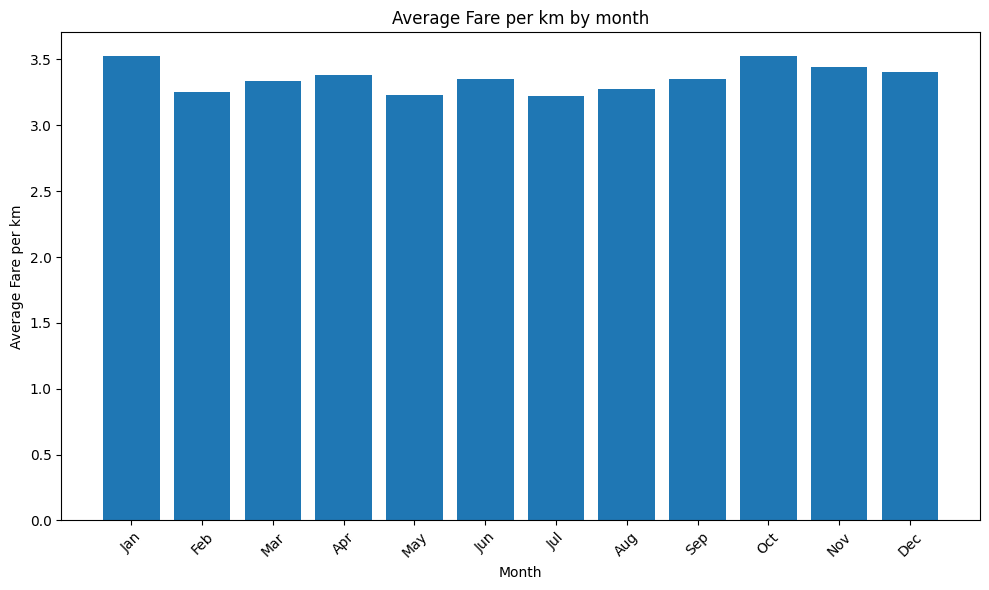

In [37]:
plt.figure(figsize=(10, 6))
plt.bar(monthly_avg.index, monthly_avg.values)
plt.xlabel('Month')
plt.ylabel('Average Fare per km')
plt.title('Average Fare per km by month')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [38]:
# 6)
# Yes, there appears to be variation in fare_per_km across months. However, the difference is not relatively huge.
# 1 - Seasonal demand: Higher demand during holidays may lead to higher values
# 2 - Touristic demand: January and October seem to have the highest fare per km, might be indicating there are more tourist traffic in the area. Tourist numbers across the months should be investigated to conclude this.

# Problem 2: Seattle bicycle time series data (40 pts)

1) Load the data in `Fremont_Bridge_Bicycle_Counter.csv`.
2) Do people ride bicycle more on odd calendar days or even calendar days? (Hint: Start with creating a new column, `oddness`, and fill it with 0 or 1 by using the dates.)
3) What's the percentage difference between number of rides in odd days and that in even days?
4) How many odd and even days are there in a year? (You can consider or ignore leap years that happen every four years which add one odd day to February.)
5) Can the discrepancy between the number of rides in odd and even days from the data be explained by the difference in numbers of odd and even days in a year? Discuss quantitatively (you can use code or just make simple algebraic calculations/estimates)?


In [39]:
# 1)
df = pd.read_csv('Fremont_Bridge_Bicycle_Counter.csv').rename(columns={
                                                'Fremont Bridge Sidewalks, south of N 34th St': 'Total',
                                                'Fremont Bridge Sidewalks, south of N 34th St Cyclist East Sidewalk': 'East',
                                                'Fremont Bridge Sidewalks, south of N 34th St Cyclist West Sidewalk': 'West', 
                                                })
df['Date'] = pd.to_datetime(df['Date'])

/var/folders/5d/9l6gb_c515qgg88vn1bg1y340000gn/T/ipykernel_48726/3010103066.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'])


In [40]:
# 2)
df['oddness'] = df['Date'].dt.day % 2

# Calculate total rides for odd and even days
odd_rides = df[df['oddness'] == 1]['Total'].sum()
even_rides = df[df['oddness'] == 0]['Total'].sum()

print(f"Odd days: {odd_rides:,.0f}")
print(f"Even days: {even_rides:,.0f}")
print(f"People ride {'more' if odd_rides > even_rides else 'less'} on odd calendar days")

Odd days: 5,297,804
Even days: 5,109,952
People ride more on odd calendar days


In [41]:
# 3)
pct_diff = ((odd_rides - even_rides) / even_rides)
print(f"Percentage difference: {pct_diff}")

# 4)
# A non-leap year:
# Months with 31 days (7 months): Jan, March, May, Jul, Aug, Oct, Dec -> 16 odd, 15 even each
# Months with 30 days (4 months): Apr, Jun, Sep, Nov -> 15 odd, 15 even each
# Months with 28 days (1 month): February -> 14 odd, 14 even

odd_days_year = 7 * 16 + 4 * 15 + 14
even_days_year = 7 * 15 + 4 * 15 + 14

print(f"Odd days in non-leap year: {odd_days_year}")
print(f"Even days in non-leap year: {even_days_year}")
print(f"Difference: {odd_days_year - even_days_year} more odd days")

# Leap year: February has 29 days (15 odd, 14 even)
odd_days_leap = 7 * 16 + 4 * 15 + 15
even_days_leap = 7 * 15 + 4 * 15 + 14
print(f"Leap year: {odd_days_leap} odd, {even_days_leap} even")

Percentage difference: 0.03676198915371416
Odd days in non-leap year: 186
Even days in non-leap year: 179
Difference: 7 more odd days
Leap year: 187 odd, 179 even


In [42]:
# 5)
calendar_pct_diff = ((odd_days_year - even_days_year) / even_days_year)
print(f"# 5)")
print(f"Calendar structure explains {calendar_pct_diff} more odd days")
print(f"Observed ride difference: {pct_diff}")
print(f"Ratio: {pct_diff / calendar_pct_diff}x")

expected_odd_rides = even_rides * (odd_days_year / even_days_year)
actual_excess = odd_rides - expected_odd_rides
print(f"If calendar alone explained difference:")
print(f"Expected odd rides: {expected_odd_rides}")
print(f"Actual odd rides: {odd_rides}")
print(f"Excess/deficit: {actual_excess} rides ({(actual_excess/expected_odd_rides)*100:.2f}%)")

# I set 0.01 as the threshold, it can be adjusted here
if abs(pct_diff - calendar_pct_diff) < 0.01:
    print("The discrepancy is well-explained by calendar structure alone")
else:
    print(f"Calendar explains only part of it ({calendar_pct_diff:.2f}% vs {pct_diff:.2f}% observed)")

# 5)
Calendar structure explains 0.03910614525139665 more odd days
Observed ride difference: 0.03676198915371416
Ratio: 0.9400565797878335x
If calendar alone explained difference:
Expected odd rides: 5309782.525139664
Actual odd rides: 5297804.0
Excess/deficit: -11978.5251396643 rides (-0.23%)
The discrepancy is well-explained by calendar structure alone
